In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

plt.style.use("seaborn-v0_8-paper")  # 干净的浅色主题（可换 "default"）

mpl.rcParams.update({
    # ---- 字体 ----
    "font.family": "sans-serif",               # 可改为 "sans-serif" 或 "Times New Roman"
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    # ---- 轴线与边框 ----
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 1,
    "axes.edgecolor": "black",
    
    # ---- 刻度与网格 ----
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.major.width": 1,
    "ytick.major.width": 1,
    "grid.linestyle": "--",
    "grid.linewidth": 0.7,
    "grid.alpha": 0.4,
    
    # ---- 图例 ----
    "legend.frameon": False,
    "legend.handlelength": 1.2,
    "legend.handleheight": 0.8,
    
    # ---- 图形布局 ----
    "figure.dpi": 200,
    "figure.figsize": (6, 4),
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

## A function for combined figures of original vs. modified UND queries

In [2]:
def produce_em_f1_AA_plots(file, modifier_model, QA_model, dataset_name, em_p, f1_p, AA_p, em_y_top):
    # ========= 参数与样式 =========
    file_path = f"./output_csv/{file}.csv"

    COLORS = ["#FFD700", "#6495ED"]  # UND / FS
    LABELS = ["Original", "Modified"]

    # ========= 工具函数 =========
    def to_percent_if_needed(a: np.ndarray) -> np.ndarray:
        """若数值最大不超过 1，则乘以 100 变为百分比。"""
        a = a.astype(float)
        if np.nanmax(a) <= 1.0:
            a = a * 100.0
        return a

    def sem(a: np.ndarray) -> float:
        a = a.astype(float)
        return float(np.nanstd(a, ddof=1) / np.sqrt(np.sum(~np.isnan(a))))

    def add_pvalue_bracket(ax, text, x1=1.0, x2=2.0,
                       y_top=100.0, inset=5.0, height=2.0,
                       text_x=None, text_dy=0.6, lw=1.2):
        """
        在 y_top 下方画“∪”形括号，p 值文字在括号下方（适合 0-100% 纵轴）。
        x1/x2 是两组的横坐标（与 set_xticks 对齐），y_top 是图顶参考值（可略高于 ylim 上限），
        inset 控制括号整体下移，height 控制括号高度。
        """
        y_base = y_top - inset
        y_top_line = y_base + height
        if text_x is None:
            text_x = (x1 + x2) / 2.0
        ax.plot([x1, x1, x2, x2],
                [y_base, y_top_line, y_top_line, y_base],
                lw=lw, c="black", clip_on=False)
        ax.text(text_x, y_base - text_dy, text,
                ha="center", va="top", fontsize=11, clip_on=False)

    # ========= 读数 =========
    file = pd.read_csv(file_path)

    # ========= 准备三组数据 =========
    # 1) EM（已知是 0–1 或 0–100，统一转为百分比）
    original_em = to_percent_if_needed(file["original_em"].dropna().values)
    modified_em  = to_percent_if_needed(file["new_em"].dropna().values)

    em_means = [float(np.nanmean(original_em)), float(np.nanmean(modified_em))]
    em_sems  = [sem(original_em), sem(modified_em)]
    em_ns    = [len(original_em), len(modified_em)]

    # 2) F1
    original_f1 = to_percent_if_needed(file["original_f1"].dropna().values)
    modified_f1  = to_percent_if_needed(file["new_f1"].dropna().values)
    f1_ns  = [len(original_f1), len(modified_f1)]

    # 3) RAGAS AA short
    original_aa = to_percent_if_needed(file["original_AA"].dropna().values)
    modified_aa  = to_percent_if_needed(file["new_AA"].dropna().values)
    aa_ns  = [len(original_aa), len(modified_aa)]

    # ========= 画三联图 =========
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
    ax0, ax1, ax2 = axes

    # ---- 左：EM 柱状图 ----
    bars = ax0.bar([1, 2], em_means, yerr=em_sems,
                color=COLORS, edgecolor="black", capsize=5, width=0.6)
    ax0.set_xticks([1, 2])
    ax0.set_xticklabels(LABELS, fontsize=11)
    ax0.set_ylabel("Accuracy / Score (%)", fontsize=12)  # 与其他两图共享同一纵轴含义
    ax0.set_title("Exact Match (EM)", fontsize=13, weight="bold", pad=30)
    ax0.grid(axis="y", linestyle="--", alpha=0.5)

    # 在柱内标注均值和样本数
    for i, (bar, mean, n) in enumerate(zip(bars, em_means, em_ns)):
        height = bar.get_height()
        # 文字颜色按背景对比来简单区分（可按需微调）
        text_color = "black" if i == 0 else "white"
        ax0.text(bar.get_x() + bar.get_width()/2,
                height * 0.5,
                f"{mean:.1f}%",
                ha="center", va="center",
                color=text_color, fontsize=10, fontweight="bold")
        ax0.set_xticks([1,2])
        ax0.set_xticklabels([f"Original\n(n={em_ns[0]})", f"Modified\n(n={em_ns[1]})"], fontsize=11)

    # p 值标注（放到图顶稍上方）
    ax0.set_ylim(0, 100)
    add_pvalue_bracket(ax0, text=em_p,
                    x1=1.0, x2=2.0,
                    y_top=em_y_top, inset=5.5, height=2.0,
                    text_x=1.5, text_dy=0.7)

    # ---- 中：F1 小提琴图 ----
    for i, (vals, color) in enumerate(zip([original_f1, modified_f1], COLORS), start=1):
        parts = ax1.violinplot(vals, positions=[i],
                        showmeans=True, showmedians=False, showextrema=False)
        for pc in parts['bodies']:
            pc.set_facecolor(color)
            pc.set_edgecolor('black')
            pc.set_alpha(0.65)
        # 均值点与标签
        m = float(np.mean(vals))
        ax1.scatter(i, m, s=34, color="black", zorder=3)
        ax1.text(i, min(m + 2.5, 96.0), f"Mean = {m:.1f}%",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

    ax1.set_xticks([1, 2])
    ax1.set_xticklabels([f"Original\n(n={f1_ns[0]})", f"Modified\n(n={f1_ns[1]})"], fontsize=11)
    ax1.set_title("F1", fontsize=13, weight="bold", pad=30)
    ax1.grid(axis="y", linestyle="--", alpha=0.5)
    ax1.set_ylim(0, 100)
    add_pvalue_bracket(ax1, text=f1_p,
                        x1=1.0, x2=2.0,
                        y_top=108.0, inset=5.5, height=2.0,
                        text_x=1.5, text_dy=0.7)

    # ---- 右：RAGAS AA (short) 小提琴图 ----
    for i, (vals, color) in enumerate(zip([original_aa, modified_aa], COLORS), start=1):
        parts = ax2.violinplot(vals, positions=[i],
                           showmeans=True, showmedians=False, showextrema=False)
        for pc in parts['bodies']:
            pc.set_facecolor(color)
            pc.set_edgecolor('black')
            pc.set_alpha(0.65)
        m = float(np.mean(vals))
        ax2.scatter(i, m, s=34, color="black", zorder=3)
        ax2.text(i, min(m + 2.5, 96.0), f"Mean = {m:.1f}%",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

    ax2.set_xticks([1, 2])
    ax2.set_xticklabels([f"Original\n(n={aa_ns[0]})", f"Modified\n(n={aa_ns[1]})"], fontsize=11)
    ax2.set_title("Nvidia Answer Accuracy (AA)", fontsize=13, weight="bold", pad=30)
    ax2.grid(axis="y", linestyle="--", alpha=0.5)
    ax2.set_ylim(0, 100)
    add_pvalue_bracket(ax2, text=AA_p,
                    x1=1.0, x2=2.0,
                    y_top=108.0, inset=5.5, height=2.0,
                    text_x=1.5, text_dy=0.7)

    # ---- 总标题与布局 ----
    fig.suptitle(f"The QA Performance of {QA_model} on original and {modifier_model} rewritten UND queries of {dataset_name} — Exact Match (EM) / F1 / Nvidia Answer Accuracy (AA)", fontsize=14, weight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

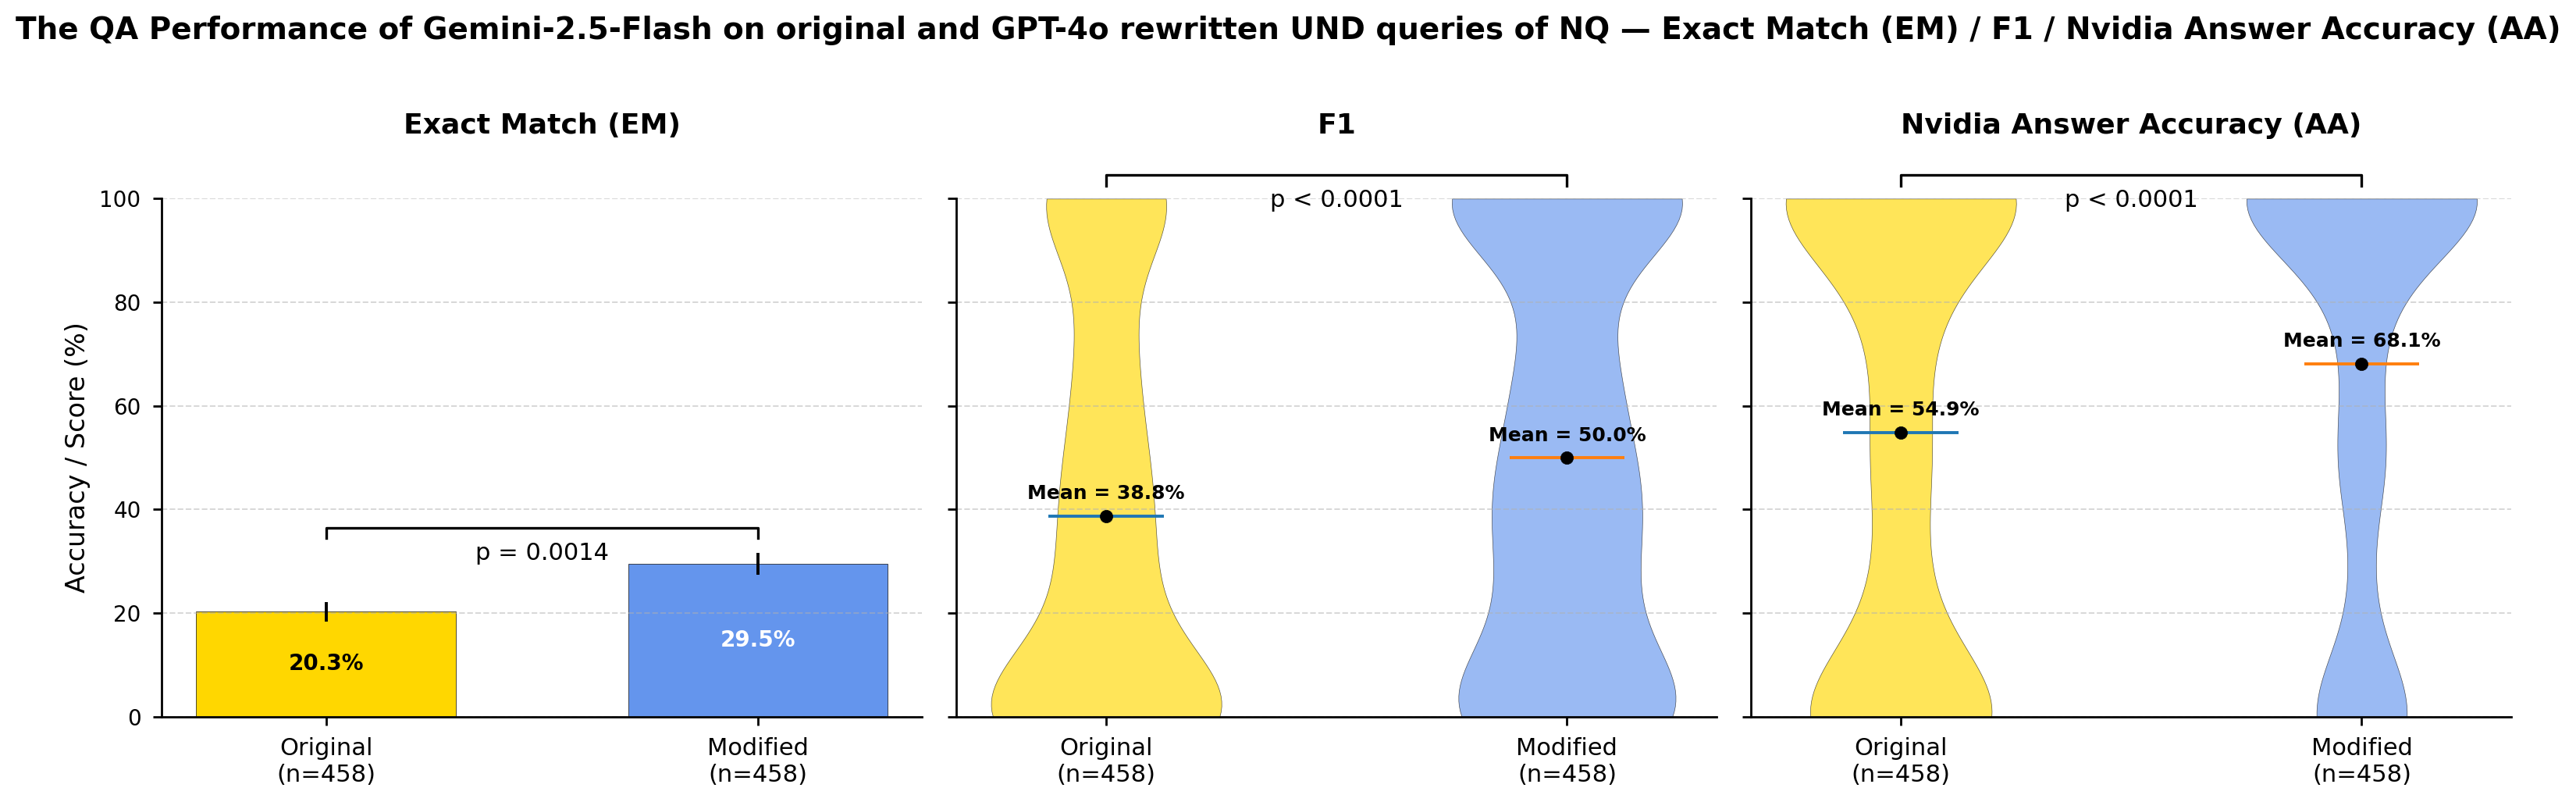

In [3]:
produce_em_f1_AA_plots('MODIFIED_gpt4o_GoogleNQ_UND_Gemini_all_new_scores', 'GPT-4o', 'Gemini-2.5-Flash', 'NQ', 'p = 0.0014', 'p < 0.0001', 'p < 0.0001', 40.0)

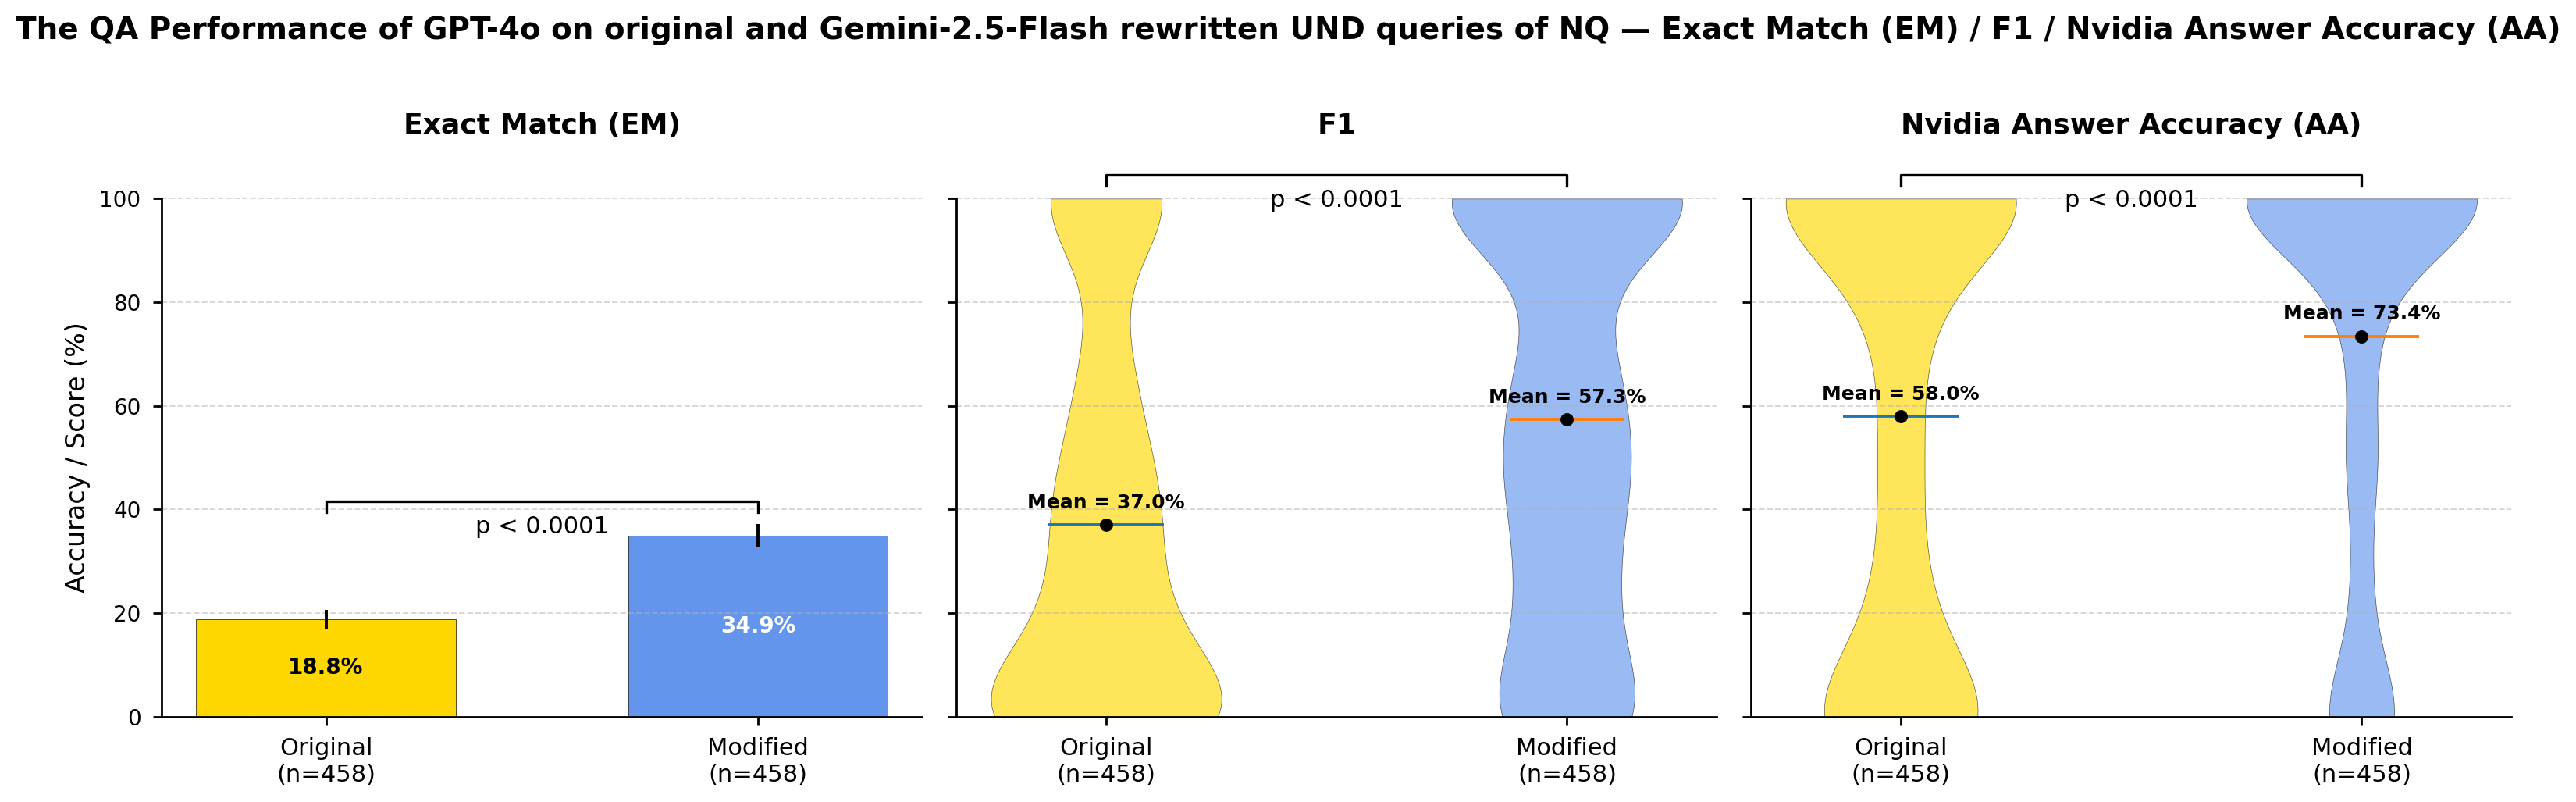

In [5]:
produce_em_f1_AA_plots('MODIFIED_Gemini_GoogleNQ_UND_gpt4o_all_new_scores', 'Gemini-2.5-Flash', 'GPT-4o', 'NQ', 'p < 0.0001', 'p < 0.0001', 'p < 0.0001', 45.0)

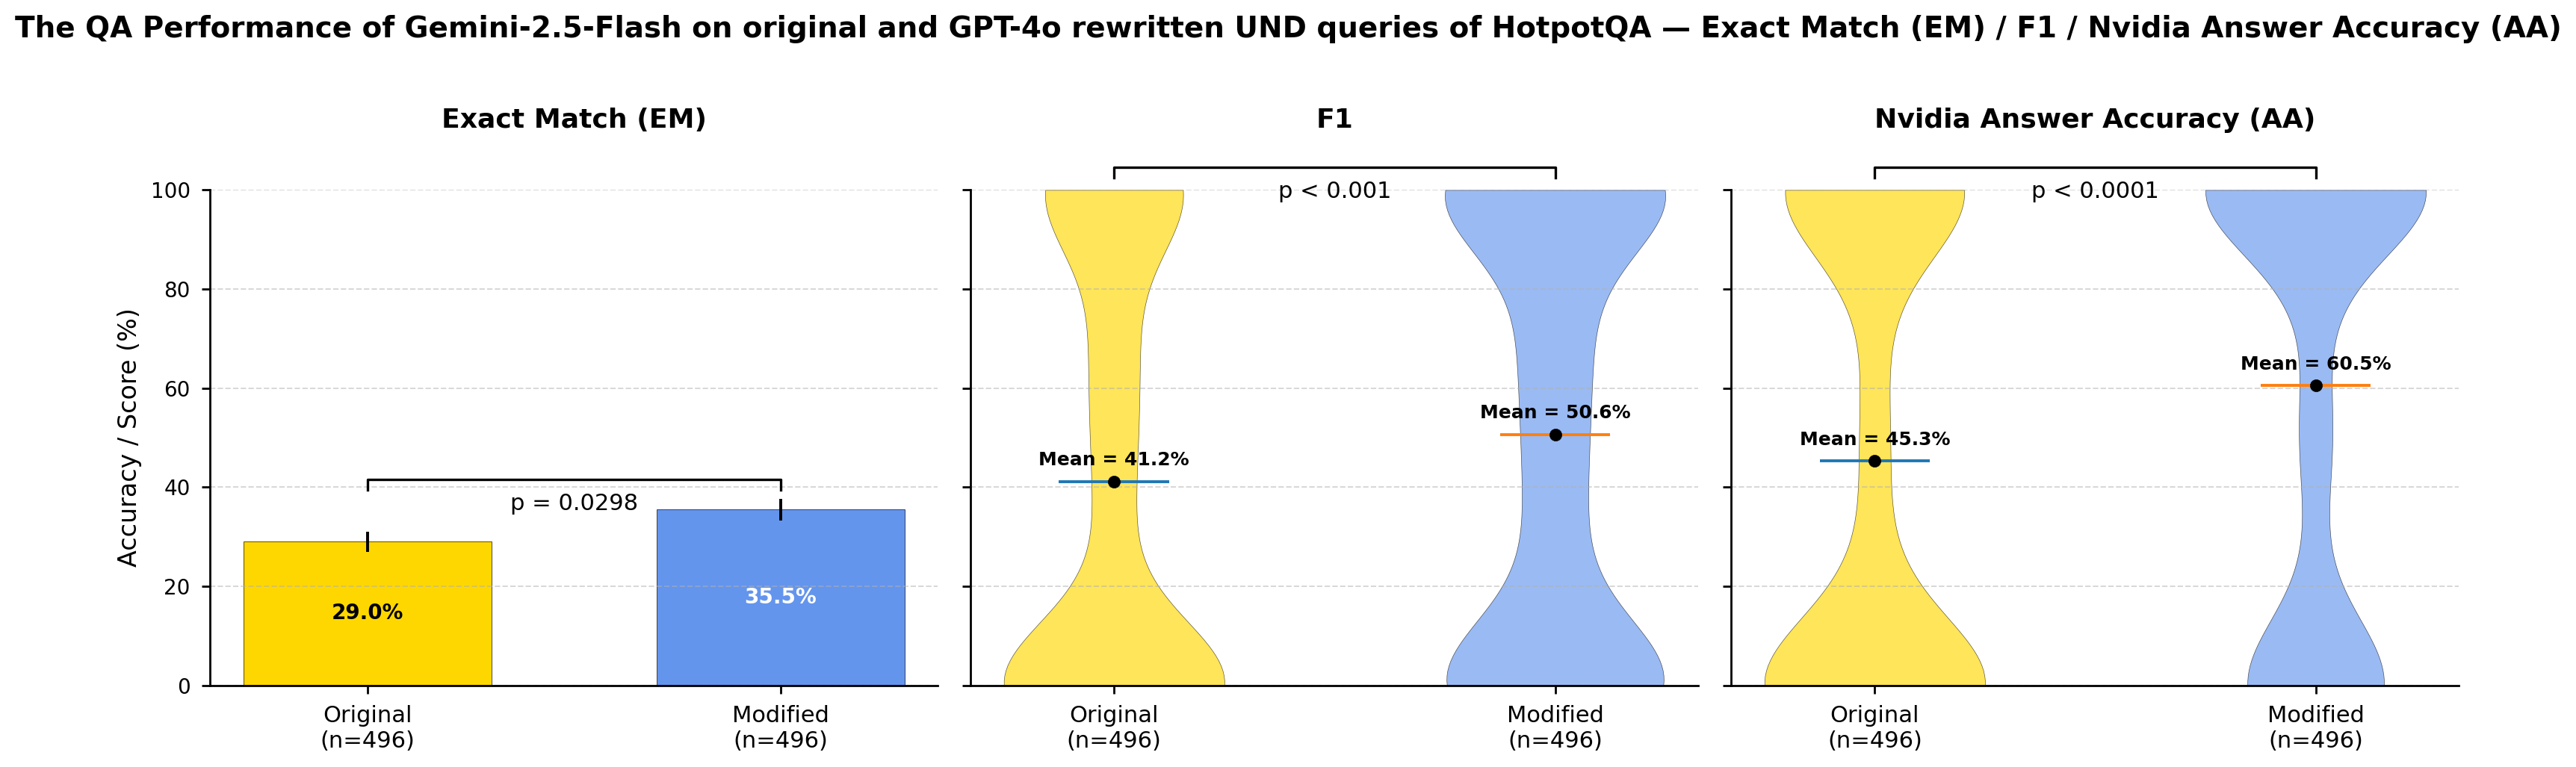

In [7]:
produce_em_f1_AA_plots('MODIFIED_gpt4o_HotpotQA_UND_Gemini_all_new_scores', 'GPT-4o', 'Gemini-2.5-Flash', 'HotpotQA', 'p = 0.0298', 'p < 0.001', 'p < 0.0001', 45.0)

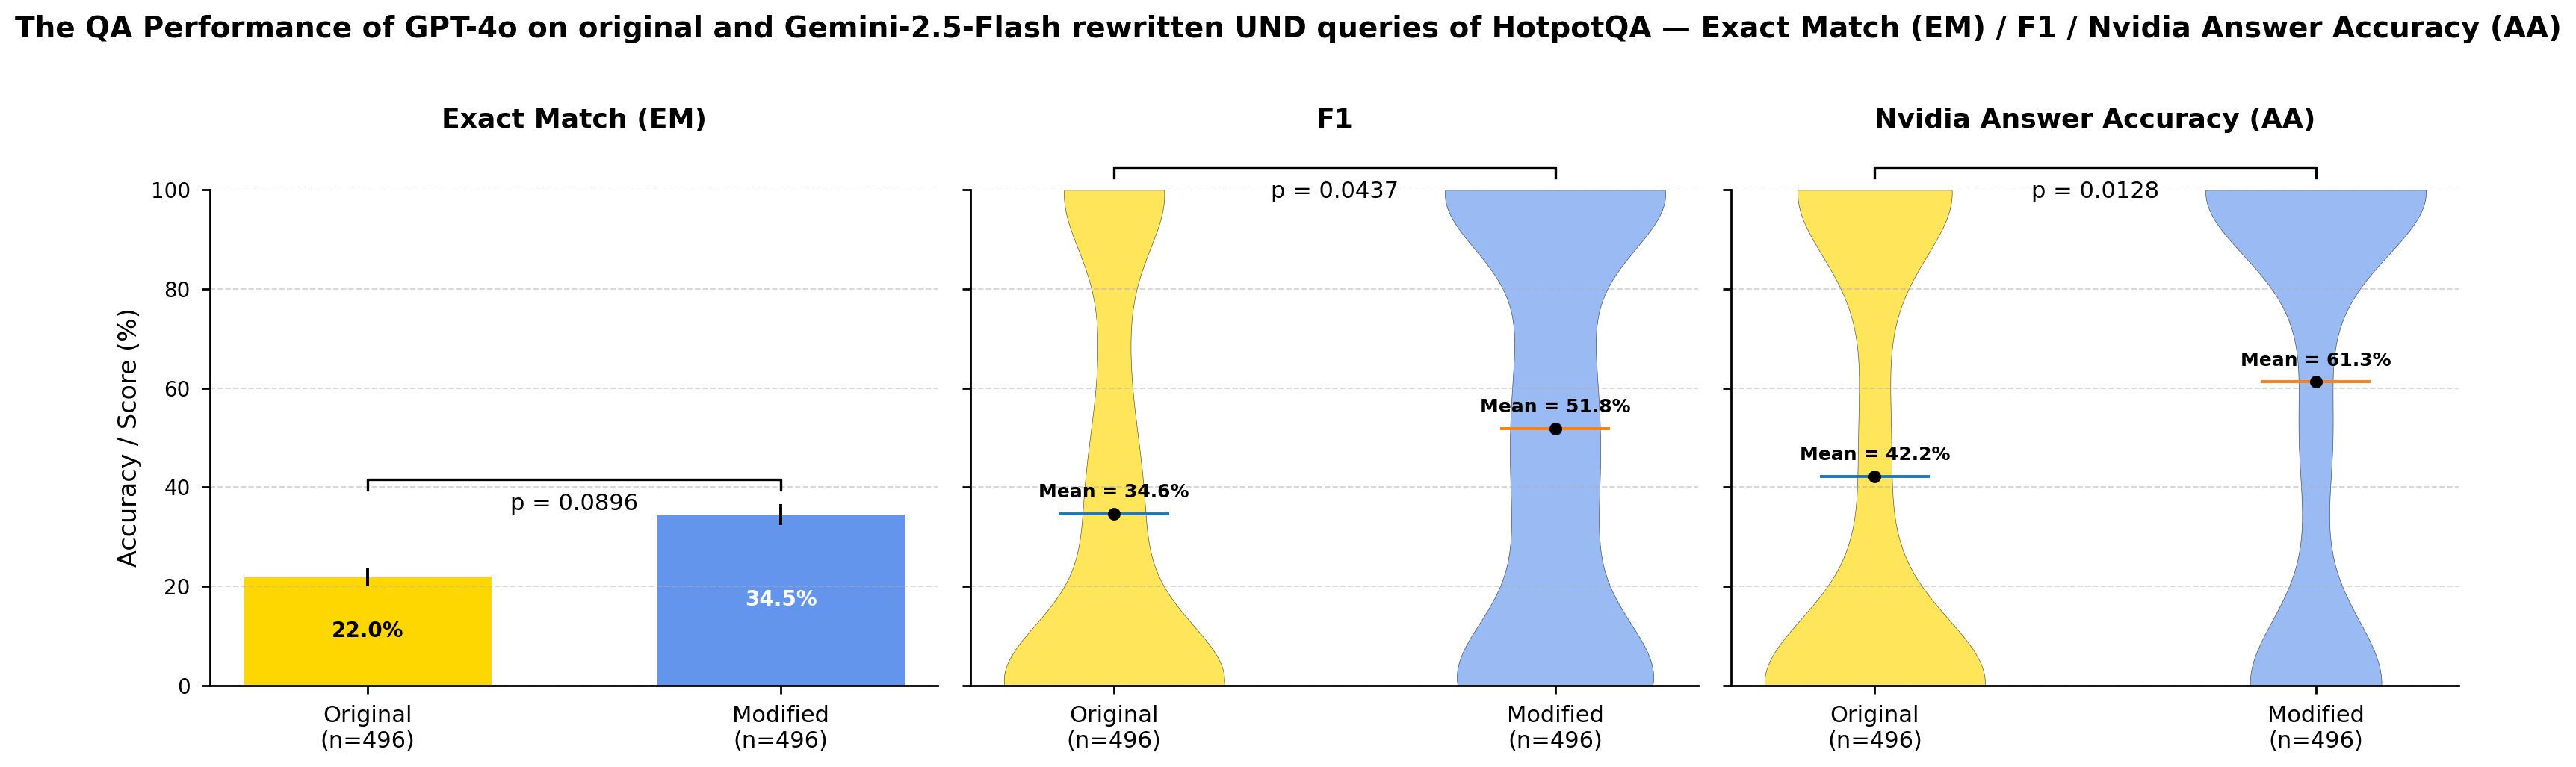

In [21]:
produce_em_f1_AA_plots('MODIFIED_Gemini_HotpotQA_UND_gpt4o_all_new_scores', 'Gemini-2.5-Flash', 'GPT-4o', 'HotpotQA', 'p = 0.0896', 'p = 0.0437', 'p = 0.0128', 45.0)

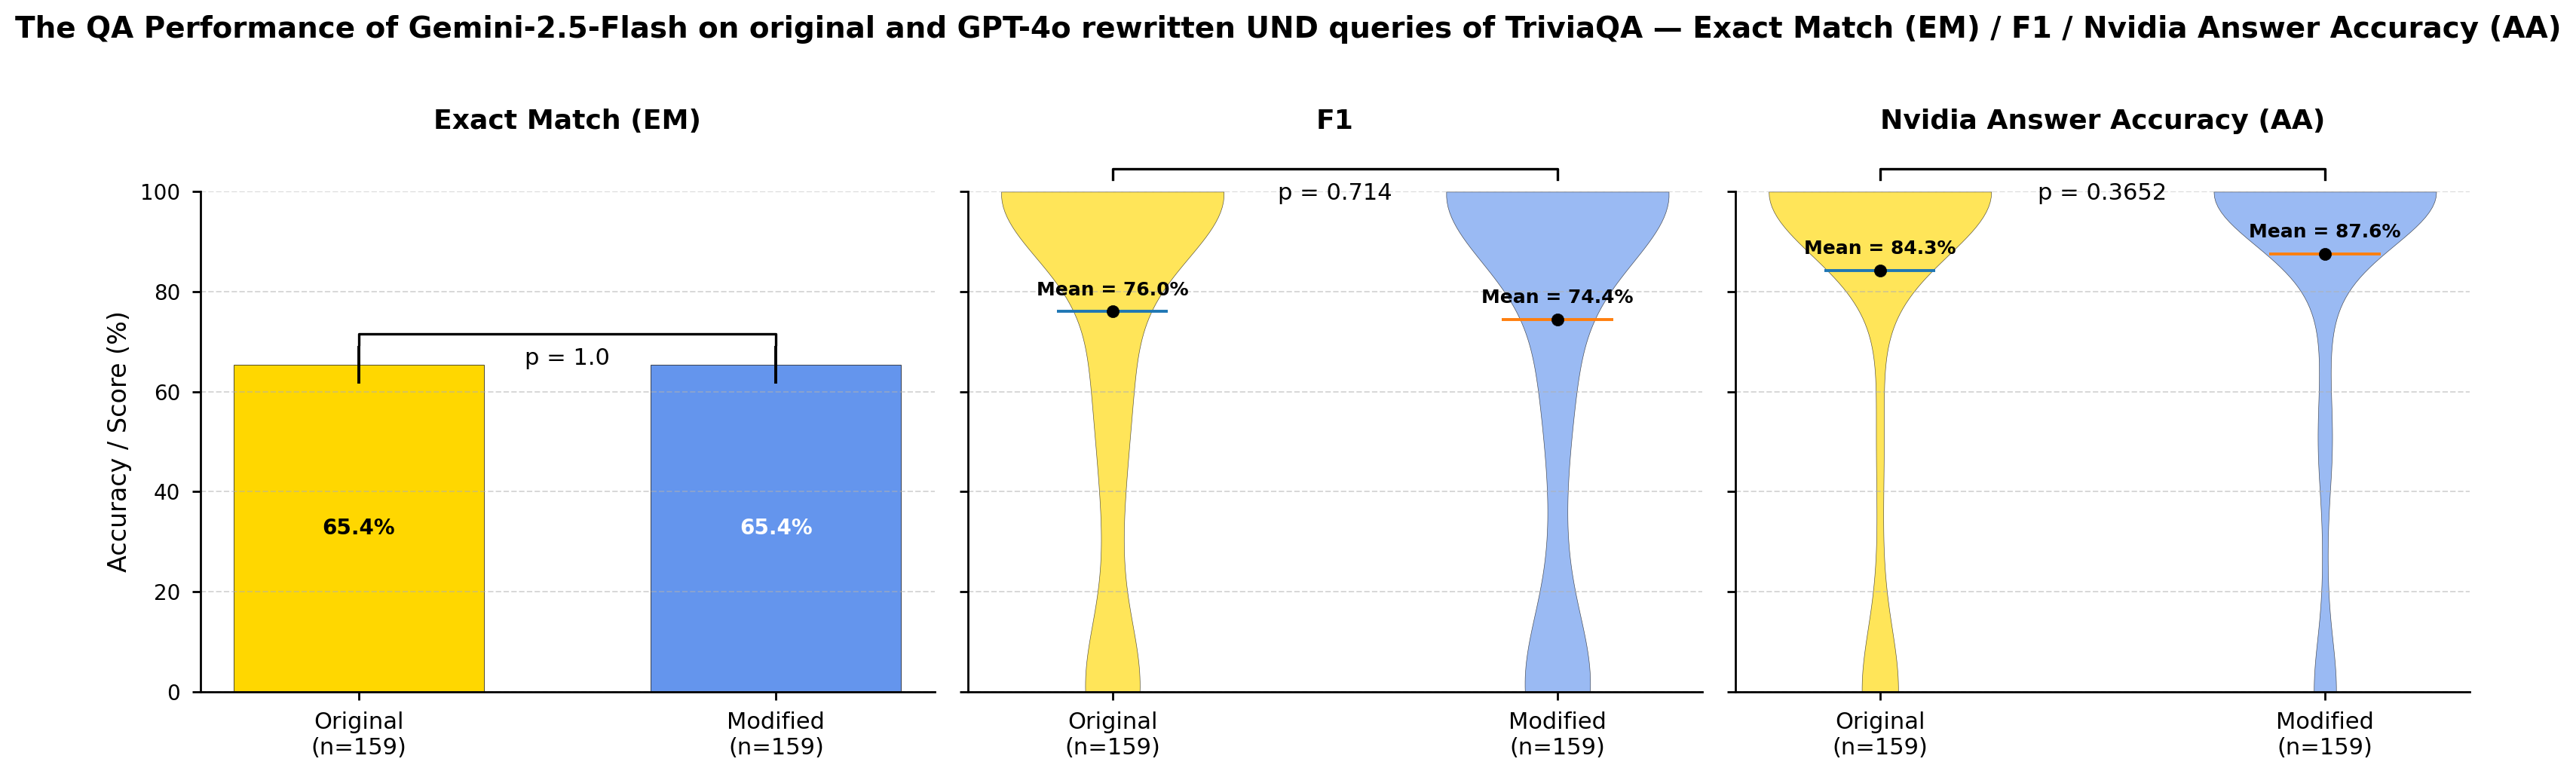

In [22]:
produce_em_f1_AA_plots('MODIFIED_gpt4o_TriviaQA_UND_Gemini_all_new_scores', 'GPT-4o', 'Gemini-2.5-Flash', 'TriviaQA', 'p = 1.0', 'p = 0.714', 'p = 0.3652', 75.0)

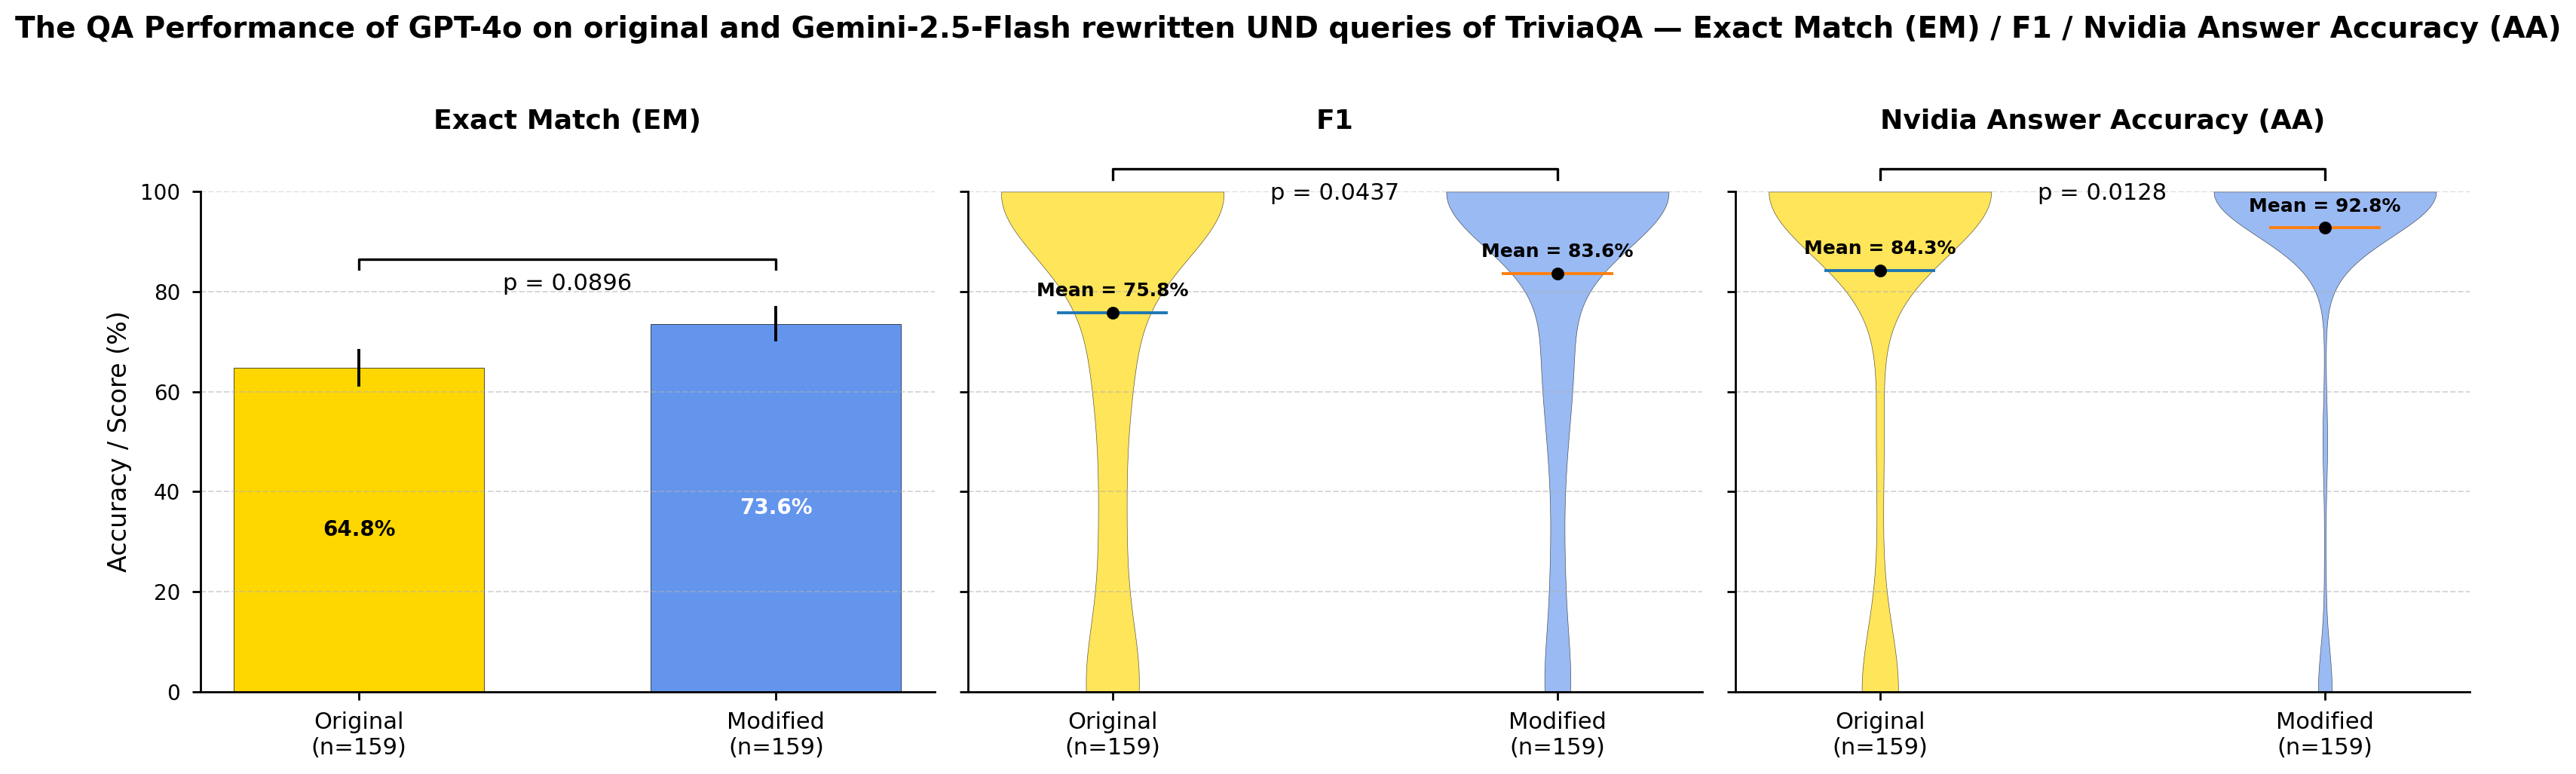

In [3]:
produce_em_f1_AA_plots('MODIFIED_Gemini_TriviaQA_UND_gpt4o_all_new_scores', 'Gemini-2.5-Flash', 'GPT-4o', 'TriviaQA', 'p = 0.0896', 'p = 0.0437', 'p = 0.0128', 90.0)

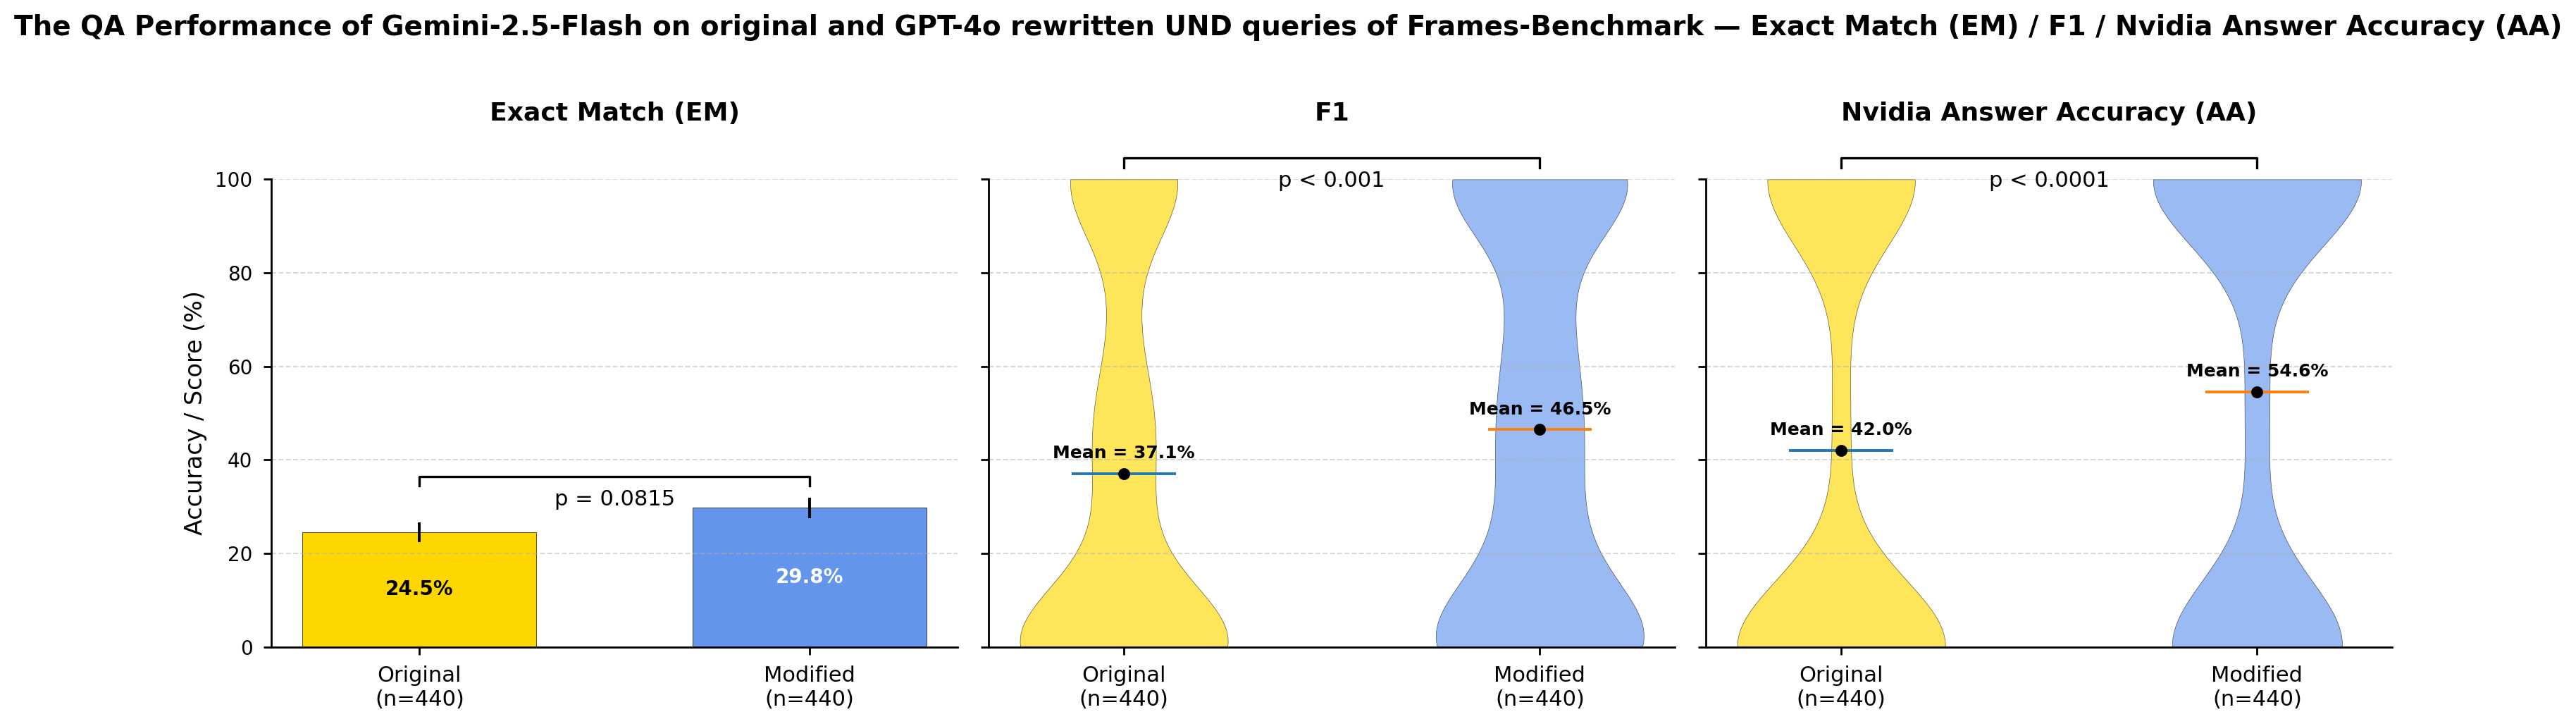

In [11]:
produce_em_f1_AA_plots('MODIFIED_gpt4o_frames_UND_Gemini_all_new_scores', 'GPT-4o', 'Gemini-2.5-Flash', 'Frames-Benchmark', 'p = 0.0815', 'p < 0.001', 'p < 0.0001', 40.0)

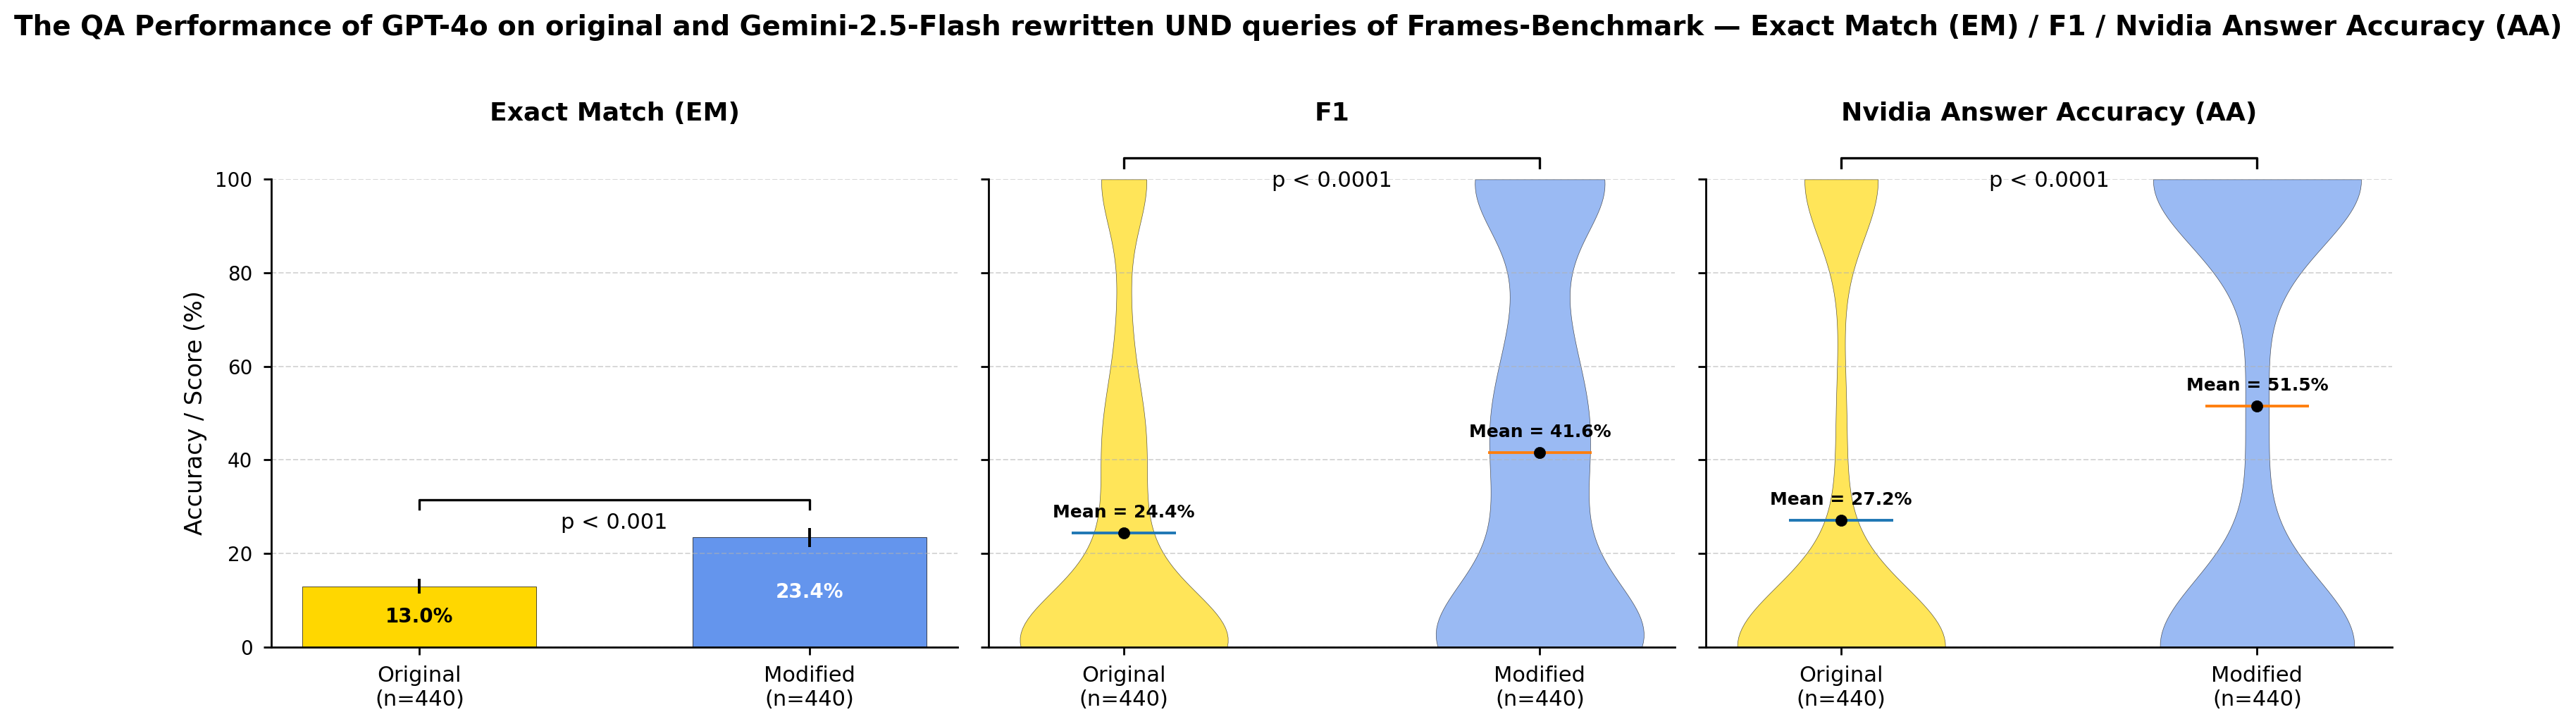

In [14]:
produce_em_f1_AA_plots('MODIFIED_Gemini_frames_UND_gpt4o_all_new_scores', 'Gemini-2.5-Flash', 'GPT-4o', 'Frames-Benchmark', 'p < 0.001', 'p < 0.0001', 'p < 0.0001', 35.0)

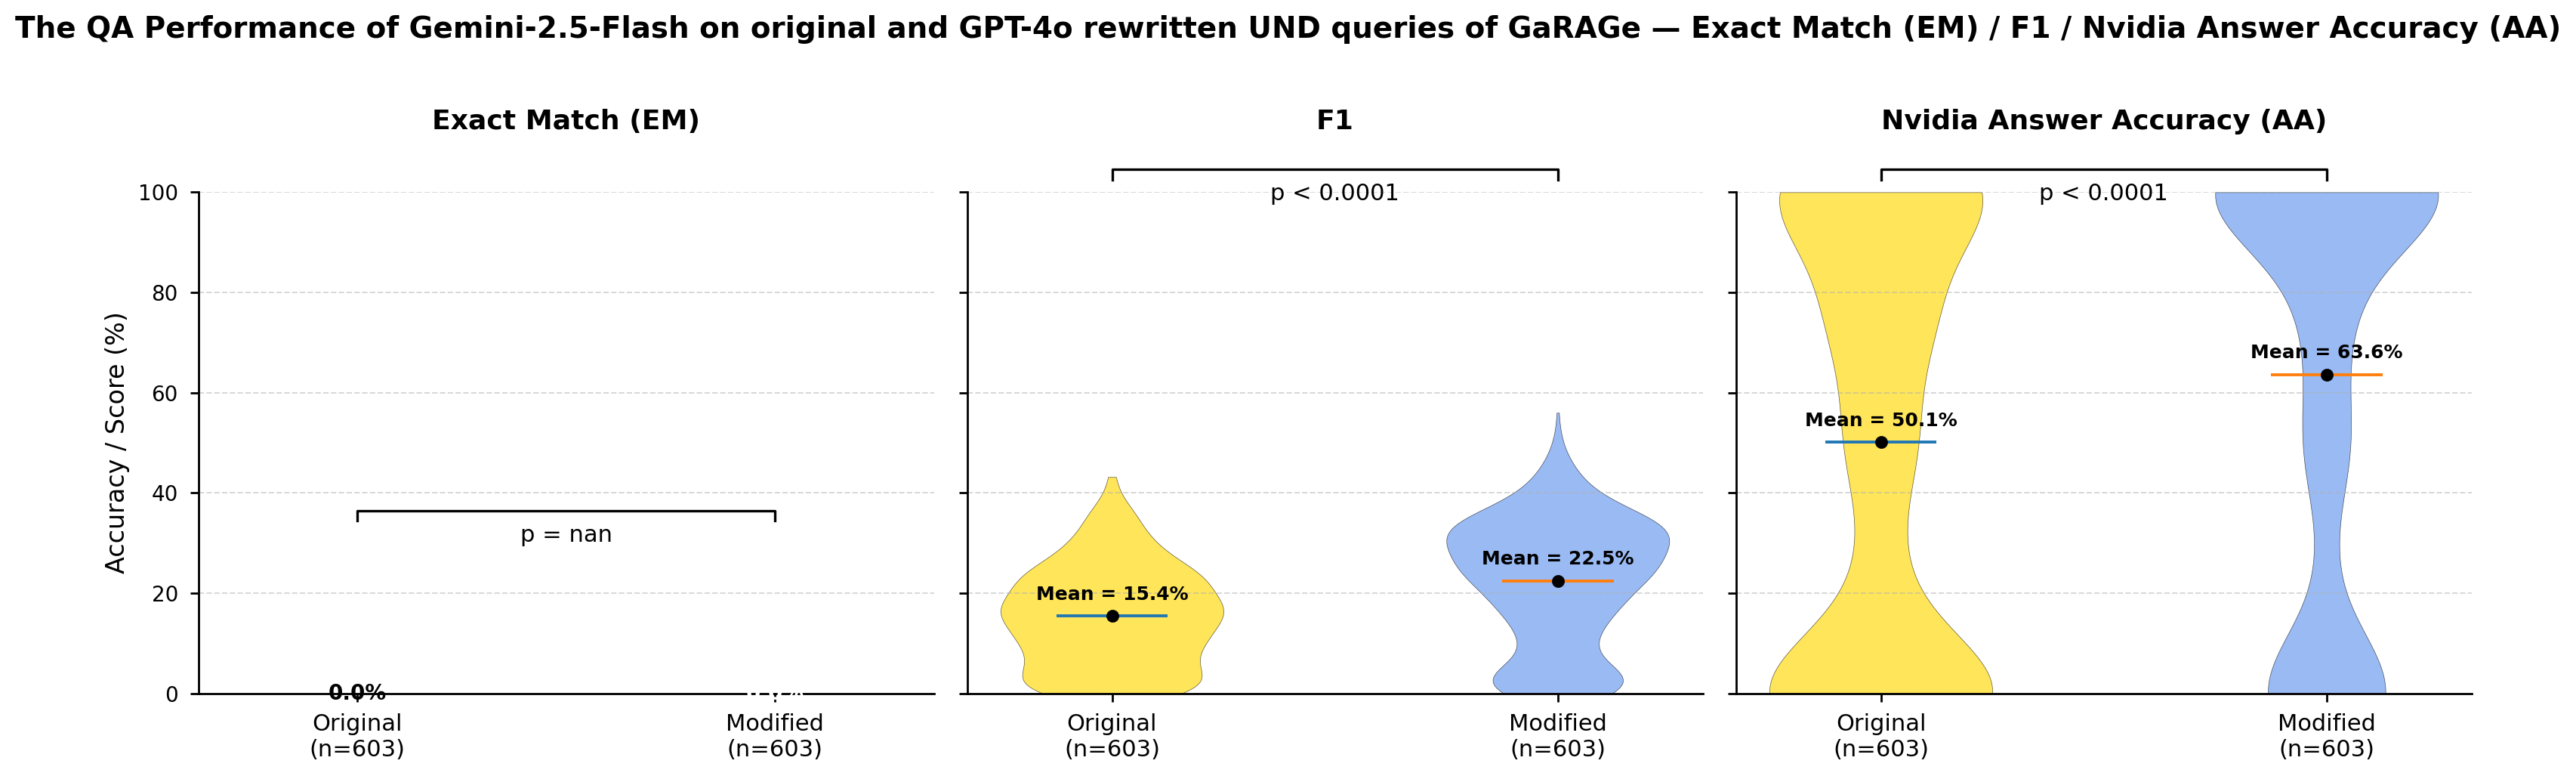

In [15]:
produce_em_f1_AA_plots('MODIFIED_gpt4o_GaRAGe_UND_Gemini_all_new_scores', 'GPT-4o', 'Gemini-2.5-Flash', 'GaRAGe', 'p = nan', 'p < 0.0001', 'p < 0.0001', 40.0)

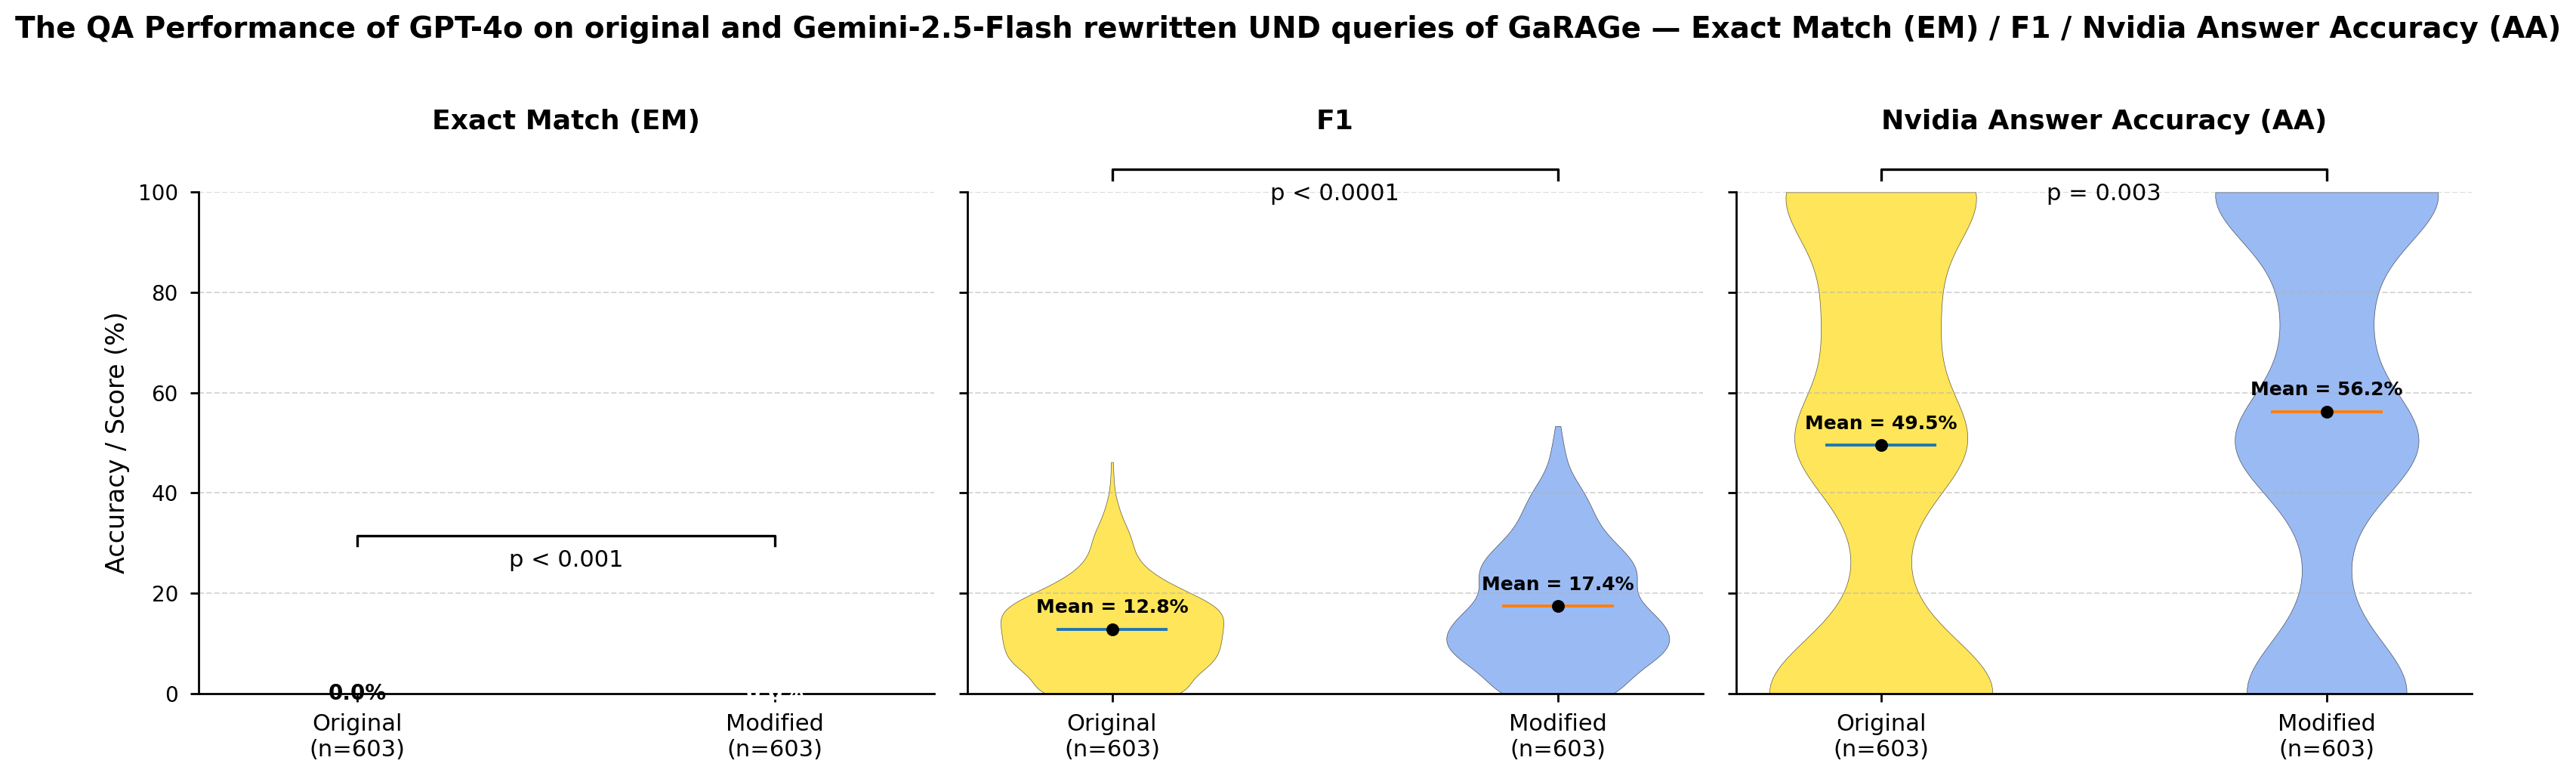

In [16]:
produce_em_f1_AA_plots('MODIFIED_Gemini_GaRAGe_UND_gpt4o_all_new_scores', 'Gemini-2.5-Flash', 'GPT-4o', 'GaRAGe', 'p < 0.001', 'p < 0.0001', 'p = 0.003', 35.0)

## Special Treatments for GaRAGe

In [17]:
def to_percent_if_needed(a: np.ndarray) -> np.ndarray:
        """若数值最大不超过 1，则乘以 100 变为百分比。"""
        a = a.astype(float)
        if np.nanmax(a) <= 1.0:
            a = a * 100.0
        return a

def sem(a: np.ndarray) -> float:
    a = a.astype(float)
    return float(np.nanstd(a, ddof=1) / np.sqrt(np.sum(~np.isnan(a))))

def add_pvalue_bracket(ax, text, x1=1.0, x2=2.0,
                       y_top=100.0, inset=5.0, height=2.0,
                       text_x=None, text_dy=0.6, lw=1.2):
    """
    在 y_top 下方画“∪”形括号，p 值文字在括号下方（适合 0-100% 纵轴）。
    x1/x2 是两组的横坐标（与 set_xticks 对齐），y_top 是图顶参考值（可略高于 ylim 上限），
    inset 控制括号整体下移，height 控制括号高度。
    """
    y_base = y_top - inset
    y_top_line = y_base + height
    if text_x is None:
        text_x = (x1 + x2) / 2.0
    ax.plot([x1, x1, x2, x2],
            [y_base, y_top_line, y_top_line, y_base],
            lw=lw, c="black", clip_on=False)
    ax.text(text_x, y_base - text_dy, text,
            ha="center", va="top", fontsize=11, clip_on=False)

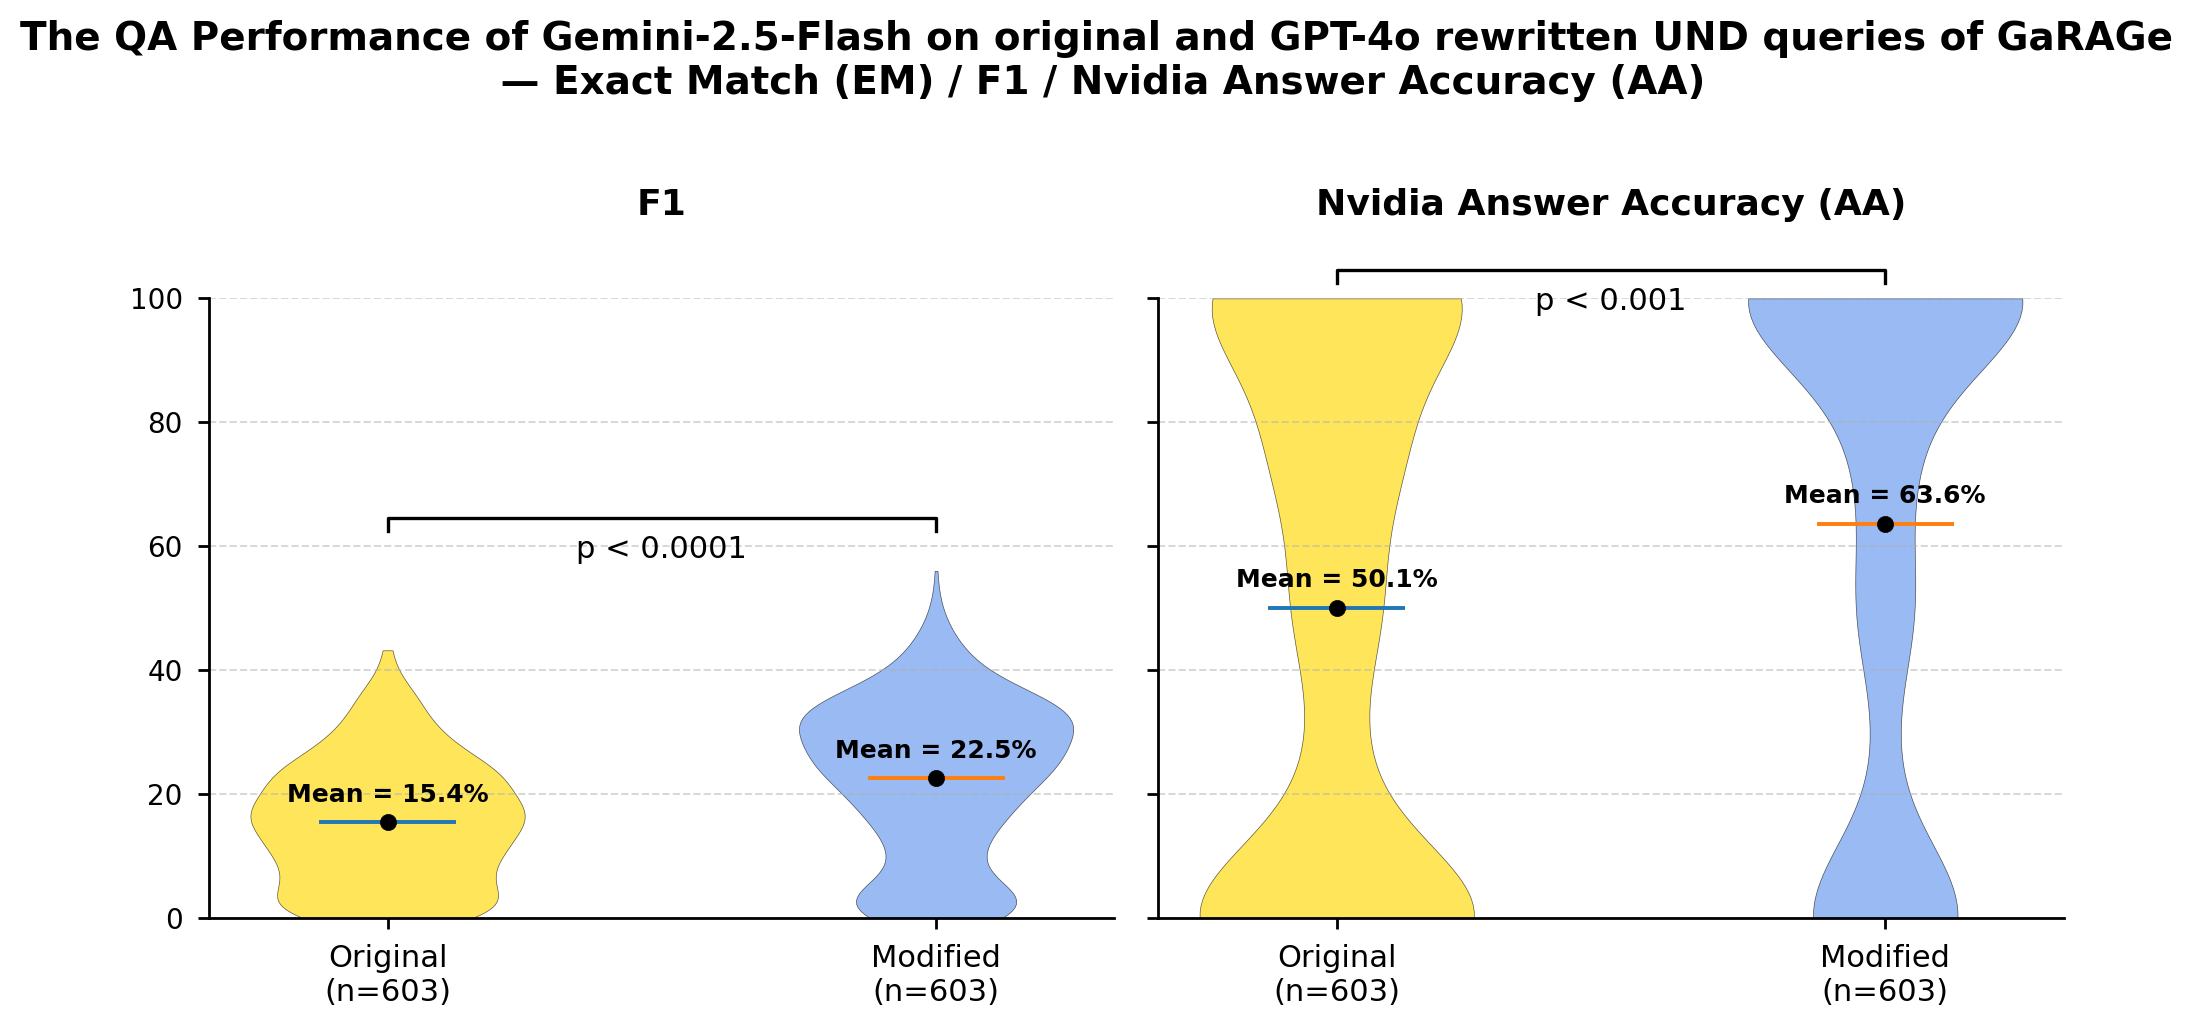

In [24]:
file_path = './output_csv/MODIFIED_gpt4o_GaRAGe_UND_Gemini_all_new_scores.csv'
COLORS = ["#FFD700", "#6495ED"]  # UND / FS
LABELS = ["Original", "Modified"]

# ========= 读数 =========
file = pd.read_csv(file_path)

# ========= 准备两组数据 =========
# 2) F1
original_f1 = to_percent_if_needed(file["original_f1"].dropna().values)
modified_f1  = to_percent_if_needed(file["new_f1"].dropna().values)
f1_ns  = [len(original_f1), len(modified_f1)]

# 3) RAGAS AA short
original_aa = to_percent_if_needed(file["original_AA"].dropna().values)
modified_aa  = to_percent_if_needed(file["new_AA"].dropna().values)
aa_ns  = [len(original_aa), len(modified_aa)]

# ========= 画三联图 =========
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
ax1, ax2 = axes

# ---- 左：F1 小提琴图 ----
for i, (vals, color) in enumerate(zip([original_f1, modified_f1], COLORS), start=1):
    parts = ax1.violinplot(vals, positions=[i],
                    showmeans=True, showmedians=False, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor(color)
        pc.set_edgecolor('black')
        pc.set_alpha(0.65)
    # 均值点与标签
    m = float(np.mean(vals))
    ax1.scatter(i, m, s=34, color="black", zorder=3)
    ax1.text(i, min(m + 2.5, 96.0), f"Mean = {m:.1f}%",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

ax1.set_xticks([1, 2])
ax1.set_xticklabels([f"Original\n(n={f1_ns[0]})", f"Modified\n(n={f1_ns[1]})"], fontsize=11)
ax1.set_title("F1", fontsize=13, weight="bold", pad=30)
ax1.grid(axis="y", linestyle="--", alpha=0.5)
ax1.set_ylim(0, 100)
add_pvalue_bracket(ax1, text='p < 0.0001',
                    x1=1.0, x2=2.0,
                    y_top=68.0, inset=5.5, height=2.0,
                    text_x=1.5, text_dy=0.7)

# ---- 右：RAGAS AA (short) 小提琴图 ----
for i, (vals, color) in enumerate(zip([original_aa, modified_aa], COLORS), start=1):
    parts = ax2.violinplot(vals, positions=[i],
                           showmeans=True, showmedians=False, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor(color)
        pc.set_edgecolor('black')
        pc.set_alpha(0.65)
    m = float(np.mean(vals))
    ax2.scatter(i, m, s=34, color="black", zorder=3)
    ax2.text(i, min(m + 2.5, 96.0), f"Mean = {m:.1f}%",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

ax2.set_xticks([1, 2])
ax2.set_xticklabels([f"Original\n(n={aa_ns[0]})", f"Modified\n(n={aa_ns[1]})"], fontsize=11)
ax2.set_title("Nvidia Answer Accuracy (AA)", fontsize=13, weight="bold", pad=30)
ax2.grid(axis="y", linestyle="--", alpha=0.5)
ax2.set_ylim(0, 100)
add_pvalue_bracket(ax2, text='p < 0.001',
                x1=1.0, x2=2.0,
                y_top=108.0, inset=5.5, height=2.0,
                text_x=1.5, text_dy=0.7)

# ---- 总标题与布局 ----
fig.suptitle(f"The QA Performance of Gemini-2.5-Flash on original and GPT-4o rewritten UND queries of GaRAGe\n — Exact Match (EM) / F1 / Nvidia Answer Accuracy (AA)", fontsize=14, weight="bold", y=1.02)
plt.tight_layout()
plt.show()

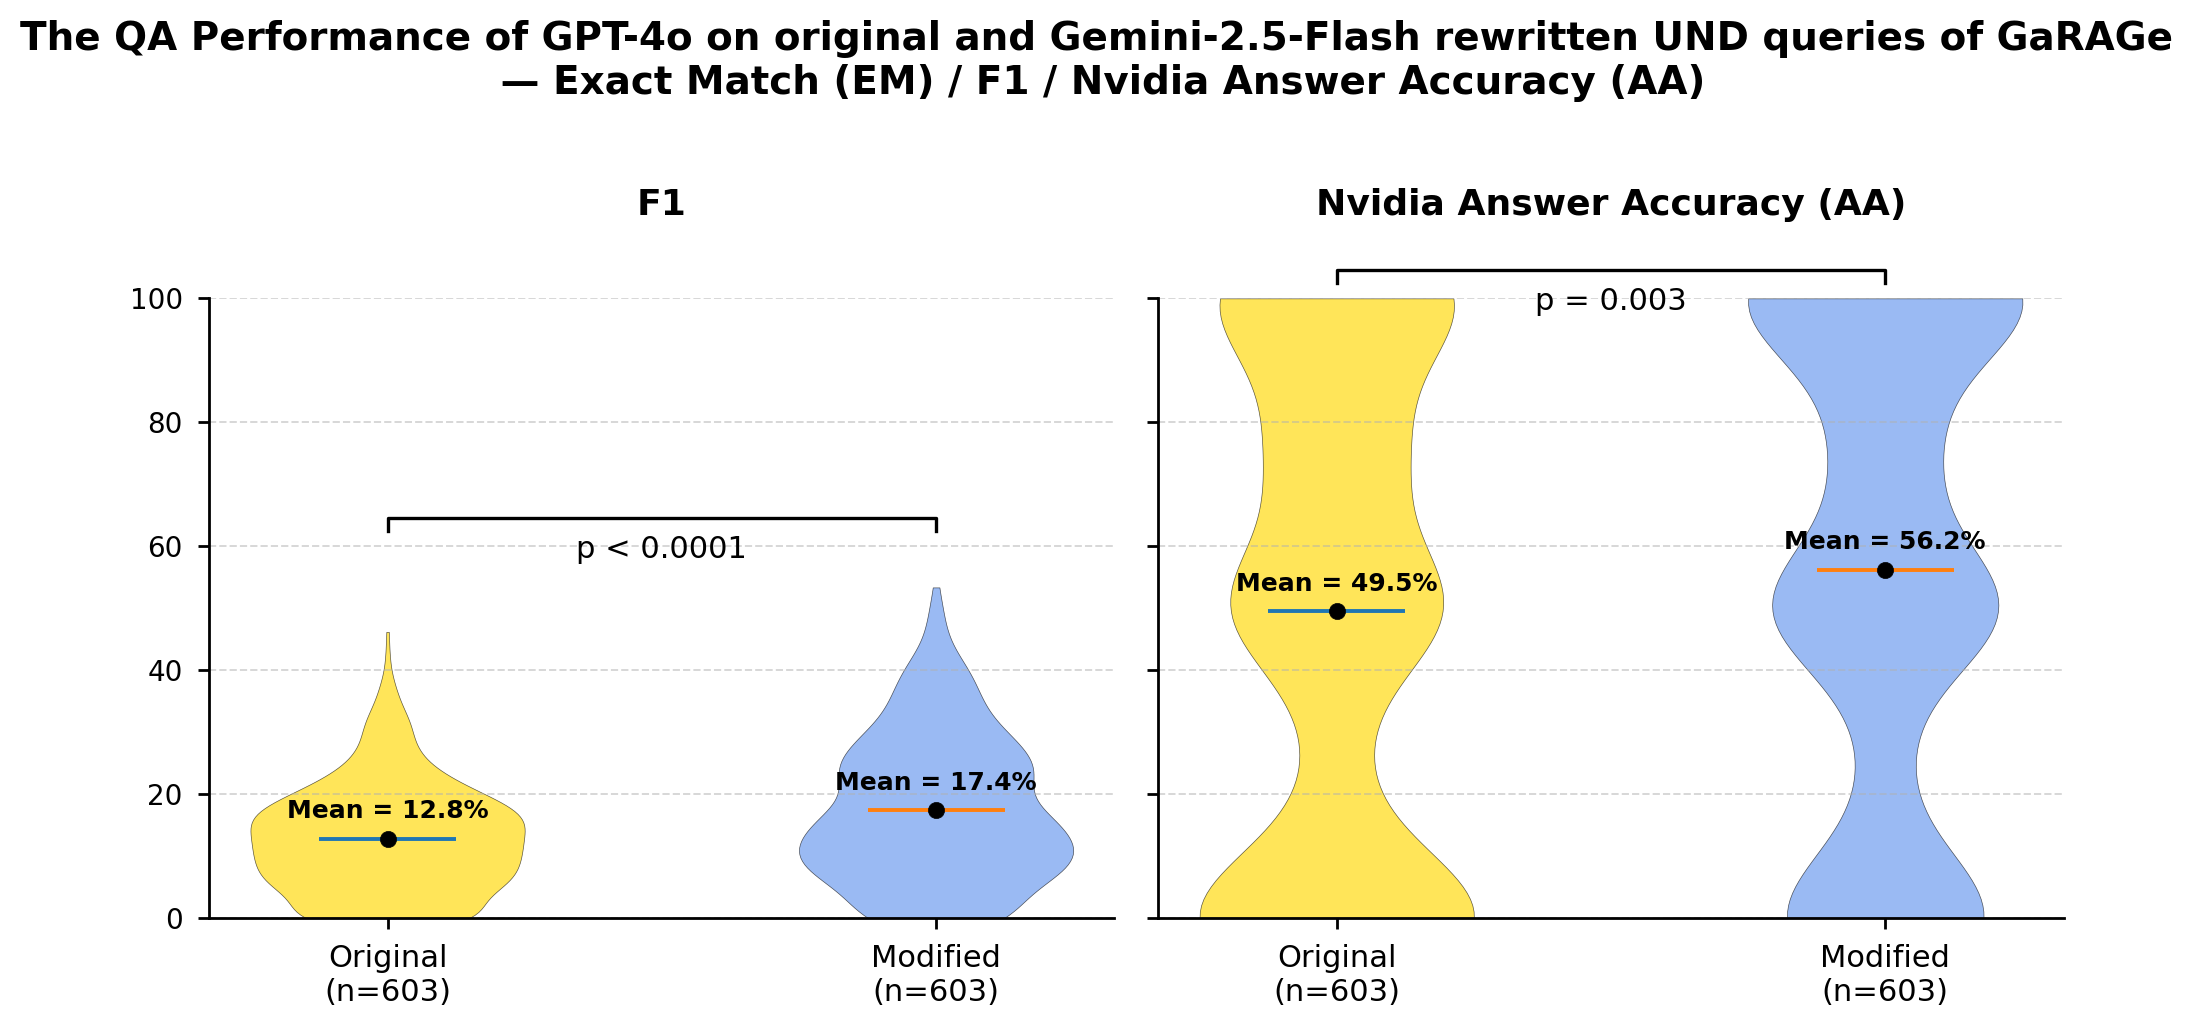

In [25]:
file_path = './output_csv/MODIFIED_Gemini_GaRAGe_UND_gpt4o_all_new_scores.csv'
COLORS = ["#FFD700", "#6495ED"]  # UND / FS
LABELS = ["Original", "Modified"]

# ========= 读数 =========
file = pd.read_csv(file_path)

# ========= 准备两组数据 =========
# 2) F1
original_f1 = to_percent_if_needed(file["original_f1"].dropna().values)
modified_f1  = to_percent_if_needed(file["new_f1"].dropna().values)
f1_ns  = [len(original_f1), len(modified_f1)]

# 3) RAGAS AA short
original_aa = to_percent_if_needed(file["original_AA"].dropna().values)
modified_aa  = to_percent_if_needed(file["new_AA"].dropna().values)
aa_ns  = [len(original_aa), len(modified_aa)]

# ========= 画三联图 =========
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
ax1, ax2 = axes

# ---- 左：F1 小提琴图 ----
for i, (vals, color) in enumerate(zip([original_f1, modified_f1], COLORS), start=1):
    parts = ax1.violinplot(vals, positions=[i],
                    showmeans=True, showmedians=False, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor(color)
        pc.set_edgecolor('black')
        pc.set_alpha(0.65)
    # 均值点与标签
    m = float(np.mean(vals))
    ax1.scatter(i, m, s=34, color="black", zorder=3)
    ax1.text(i, min(m + 2.5, 96.0), f"Mean = {m:.1f}%",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

ax1.set_xticks([1, 2])
ax1.set_xticklabels([f"Original\n(n={f1_ns[0]})", f"Modified\n(n={f1_ns[1]})"], fontsize=11)
ax1.set_title("F1", fontsize=13, weight="bold", pad=30)
ax1.grid(axis="y", linestyle="--", alpha=0.5)
ax1.set_ylim(0, 100)
add_pvalue_bracket(ax1, text='p < 0.0001',
                    x1=1.0, x2=2.0,
                    y_top=68.0, inset=5.5, height=2.0,
                    text_x=1.5, text_dy=0.7)

# ---- 右：RAGAS AA (short) 小提琴图 ----
for i, (vals, color) in enumerate(zip([original_aa, modified_aa], COLORS), start=1):
    parts = ax2.violinplot(vals, positions=[i],
                           showmeans=True, showmedians=False, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor(color)
        pc.set_edgecolor('black')
        pc.set_alpha(0.65)
    m = float(np.mean(vals))
    ax2.scatter(i, m, s=34, color="black", zorder=3)
    ax2.text(i, min(m + 2.5, 96.0), f"Mean = {m:.1f}%",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

ax2.set_xticks([1, 2])
ax2.set_xticklabels([f"Original\n(n={aa_ns[0]})", f"Modified\n(n={aa_ns[1]})"], fontsize=11)
ax2.set_title("Nvidia Answer Accuracy (AA)", fontsize=13, weight="bold", pad=30)
ax2.grid(axis="y", linestyle="--", alpha=0.5)
ax2.set_ylim(0, 100)
add_pvalue_bracket(ax2, text='p = 0.003',
                x1=1.0, x2=2.0,
                y_top=108.0, inset=5.5, height=2.0,
                text_x=1.5, text_dy=0.7)

# ---- 总标题与布局 ----
fig.suptitle(f"The QA Performance of GPT-4o on original and Gemini-2.5-Flash rewritten UND queries of GaRAGe\n — Exact Match (EM) / F1 / Nvidia Answer Accuracy (AA)", fontsize=14, weight="bold", y=1.02)
plt.tight_layout()
plt.show()

### UND post-modification classification

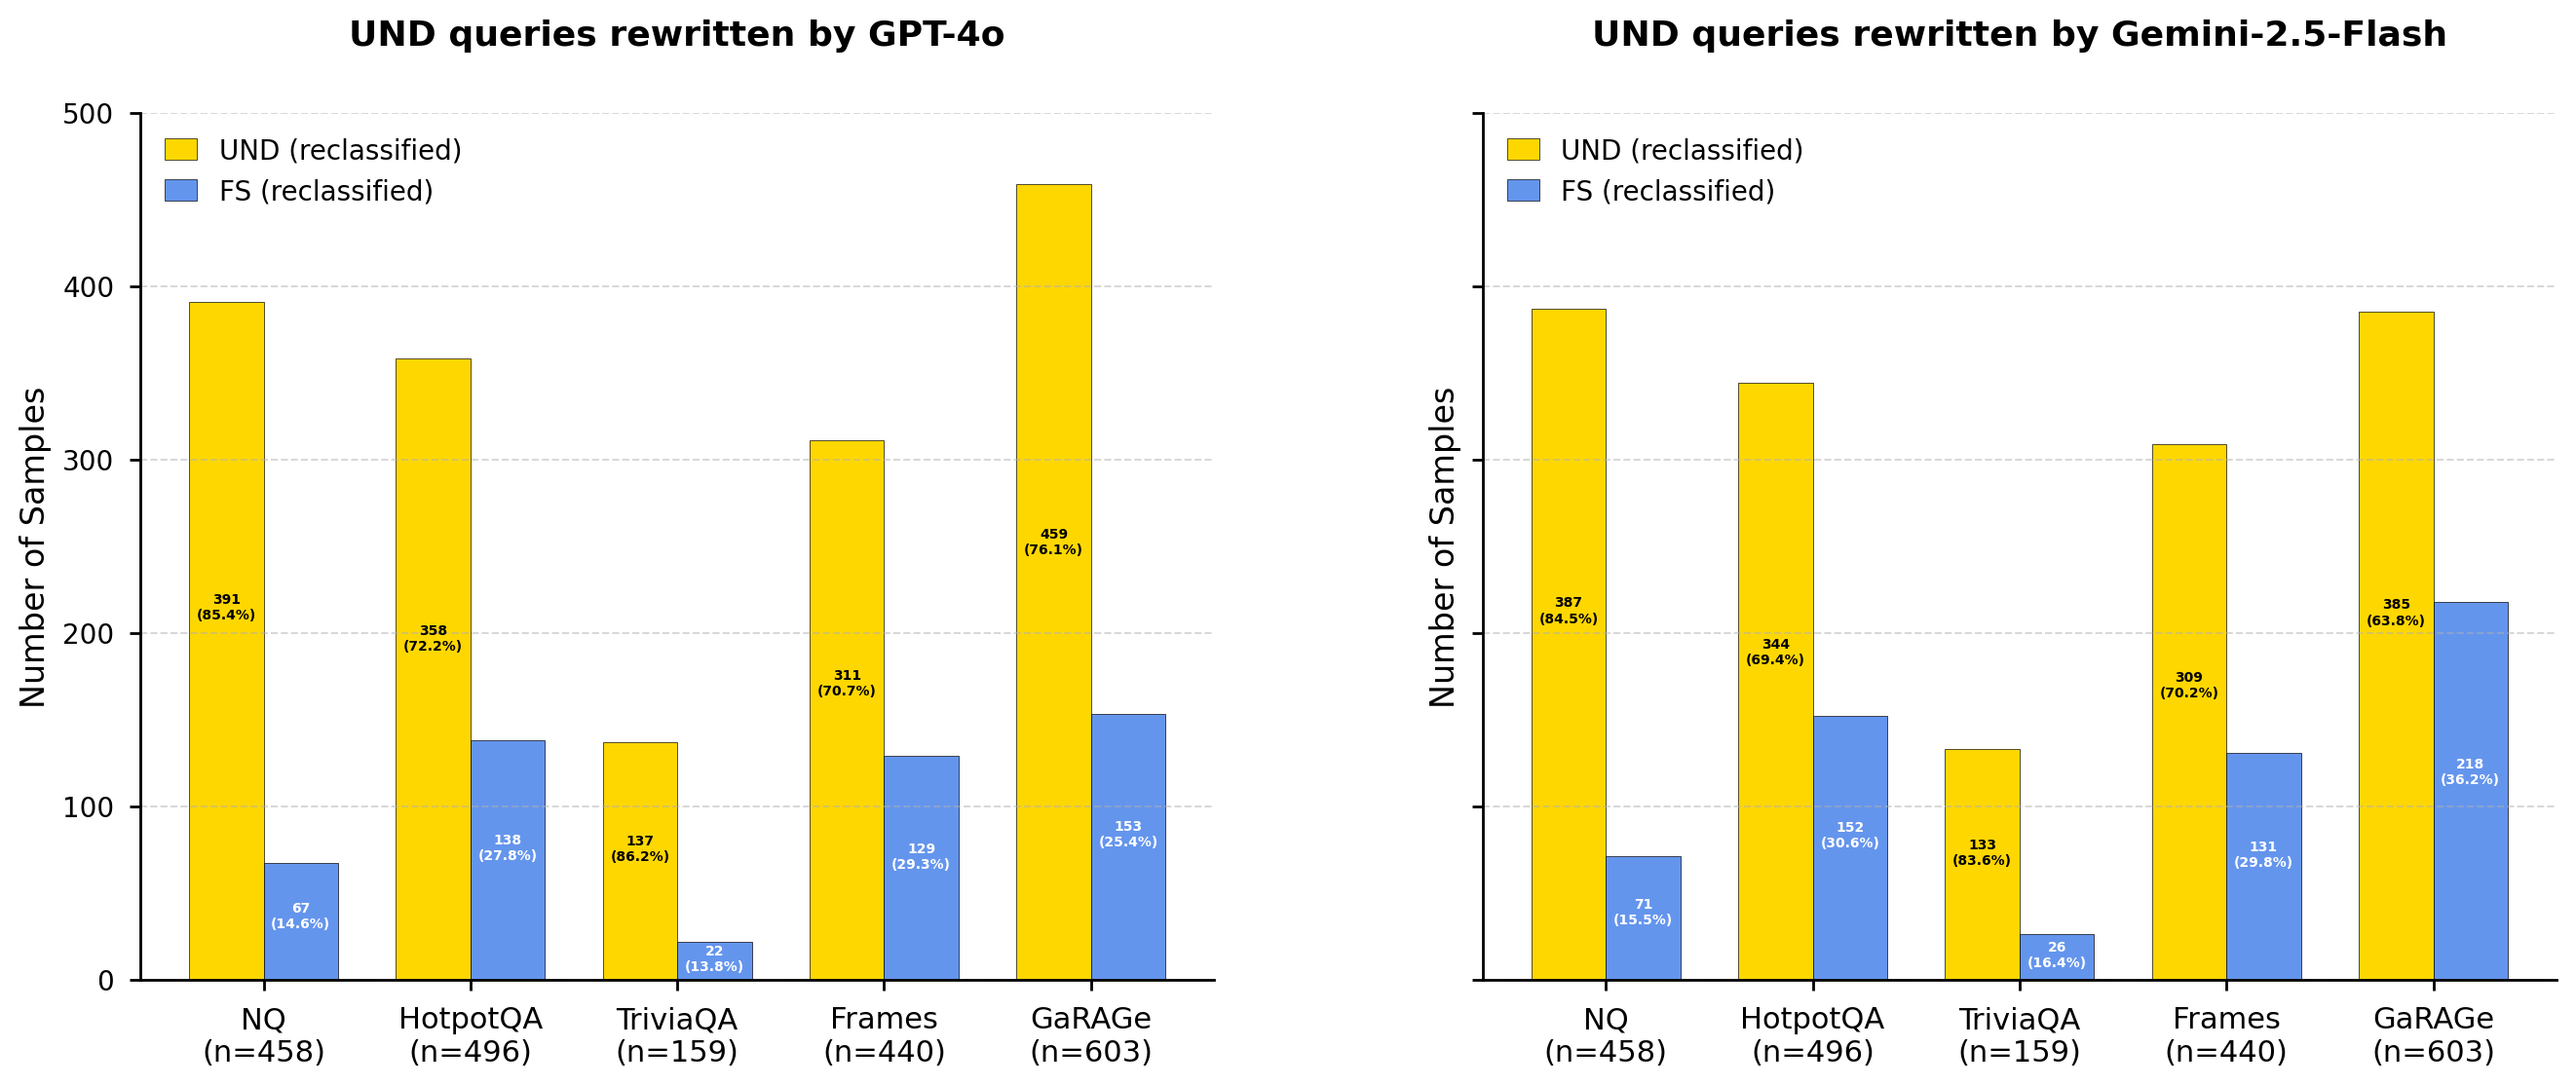

In [20]:
# ===== 数据（来自截图） =====
datasets = ["NQ", "HotpotQA", "TriviaQA", "Frames", "GaRAGe"]

# GPT-4o
gpt4o_und = np.array([391, 358, 137, 311, 459])
gpt4o_fs  = np.array([ 67, 138,  22, 129, 153])
gpt4o_tot = np.array([458, 496, 159, 440, 603])

# Gemini-2.5-Flash
gem_und = np.array([387, 344, 133, 309, 385])
gem_fs  = np.array([ 71, 152,  26, 131, 218])
gem_tot = np.array([458, 496, 159, 440, 603])

# ===== 颜色与布局 =====
colors = {"UND": "#FFD700", "FS": "#6495ED"}
bar_width = 0.36
x = np.arange(len(datasets))

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

def plot_panel(ax, und, fs, total, title):
    # 柱子
    b1 = ax.bar(x - bar_width/2, und, width=bar_width, color=colors["UND"],
                edgecolor="black", label="UND (reclassified)")
    b2 = ax.bar(x + bar_width/2, fs,  width=bar_width, color=colors["FS"],
                edgecolor="black", label="FS (reclassified)")

    # x 轴标签：数据集 + (n=总数)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{d}\n(n={n})" for d, n in zip(datasets, total)], fontsize=11)

    # 纵轴 & 标题
    ax.set_ylabel("Number of Samples")
    ax.set_title(title, pad=25, weight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.set_ylim(0,500)

    # 在柱内添加“样本数 + 占比”
    for i, (bar, cnt, tot) in enumerate(zip(b1, und, total)):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height()*0.55,
                f"{cnt}\n({cnt/tot*100:.1f}%)",
                ha="center", va="center", fontsize=5, color="black", fontweight="bold")
    for i, (bar, cnt, tot) in enumerate(zip(b2, fs, total)):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height()*0.55,
                f"{cnt}\n({cnt/tot*100:.1f}%)",
                ha="center", va="center", fontsize=5, color="white", fontweight="bold")

    ax.legend(loc="upper left")

# ===== 绘制两个面板 =====
plot_panel(axes[0], gpt4o_und, gpt4o_fs, gpt4o_tot, "UND queries rewritten by GPT-4o")
plot_panel(axes[1], gem_und,   gem_fs,   gem_tot,   "UND queries rewritten by Gemini-2.5-Flash")

# 让上边距更宽，标题不拥挤
plt.subplots_adjust(top=1, wspace=0.25)
plt.show()